In [ ]:
!pip install gymnasium
!pip install gymnasium[toy-text]
!pip install gymnasium[classic-control]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.6 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
env = gym.make("FrozenLake-v1", is_slippery=False)

In [ ]:
Q = np.zeros((env.observation_space.n,
              env.action_space.n))

print(Q.shape)

(16, 4)


In [ ]:
alpha = 0.8       # learning rate
gamma = 0.95      # discount factor

epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

episodes = 500

In [ ]:
def choose_action(state):
    if np.random.rand() < epsilon:
        return env.action_space.sample()  # explore
    else:
        return np.argmax(Q[state])        # exploit

In [ ]:
def to_int(state):
    return int(np.asarray(state).flatten()[0])

episodes = 3000
rewards = []

for ep in range(episodes):

    state, _ = env.reset()
    state = to_int(state)

    done = False
    total_reward = 0

    while not done:

        # epsilon-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = to_int(next_state)

        done = terminated or truncated

        # Q-learning update
        Q[state, action] += alpha * (
            reward +
            gamma * np.max(Q[next_state]) -
            Q[state, action]
        )

        state = next_state
        total_reward += reward

    rewards.append(total_reward)

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

In [ ]:
print("Learned Q-table:")
print(Q)

Learned Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [ ]:
print("Total successes:", sum(rewards))

Total successes: 28710.0


Q1


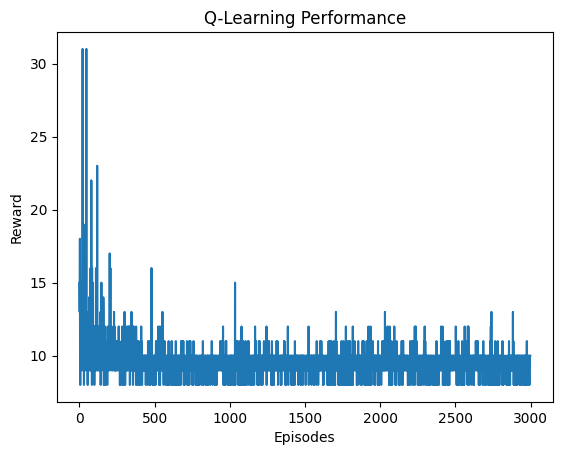

In [ ]:
plt.plot(rewards)
plt.title("Q-Learning Performance")
plt.xlabel("Episodes")
plt.ylabel("Reward")
print("Q1")
plt.show()

In [ ]:
# Q2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
env = gym.make("CartPole-v1")

state_size = env.observation_space.shape[0]
action_size = env.action_space.n

In [ ]:
class DQN(nn.Module):

    def __init__(self, state_size, action_size):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(state_size, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.01

batch_size = 32
episodes = 200

In [ ]:
model = DQN(state_size, action_size)

optimizer = optim.Adam(model.parameters(), lr=0.001)

criterion = nn.MSELoss()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
memory = deque(maxlen=2000)

In [ ]:
def remember(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

In [ ]:
def replay():

    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)

    for state, action, reward, next_state, done in batch:

        state = torch.FloatTensor(state)
        next_state = torch.FloatTensor(next_state)

        target = reward

        if not done:
            target += gamma * torch.max(model(next_state)).item()

        target_f = model(state)
        target_f[action] = target

        loss = criterion(model(state), target_f.detach())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
scores = []

for ep in range(episodes):

    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:

        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = torch.argmax(
                model(torch.FloatTensor(state))
            ).item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        remember(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        replay()

    epsilon = max(min_epsilon, epsilon * epsilon_decay)

    scores.append(total_reward)

    print(f"Episode {ep}, Score {total_reward}")

Episode 0, Score 33.0
Episode 1, Score 29.0
Episode 2, Score 43.0
Episode 3, Score 21.0
Episode 4, Score 18.0
Episode 5, Score 11.0
Episode 6, Score 15.0
Episode 7, Score 44.0
Episode 8, Score 60.0
Episode 9, Score 28.0
Episode 10, Score 18.0
Episode 11, Score 39.0
Episode 12, Score 26.0
Episode 13, Score 20.0
Episode 14, Score 33.0
Episode 15, Score 14.0
Episode 16, Score 51.0
Episode 17, Score 15.0
Episode 18, Score 18.0
Episode 19, Score 34.0
Episode 20, Score 30.0
Episode 21, Score 11.0
Episode 22, Score 21.0
Episode 23, Score 21.0
Episode 24, Score 8.0
Episode 25, Score 15.0
Episode 26, Score 13.0
Episode 27, Score 35.0
Episode 28, Score 16.0
Episode 29, Score 27.0
Episode 30, Score 26.0
Episode 31, Score 22.0
Episode 32, Score 45.0
Episode 33, Score 17.0
Episode 34, Score 14.0
Episode 35, Score 47.0
Episode 36, Score 35.0
Episode 37, Score 25.0
Episode 38, Score 21.0
Episode 39, Score 14.0
Episode 40, Score 70.0
Episode 41, Score 13.0
Episode 42, Score 65.0
Episode 43, Score 22.0

Q2


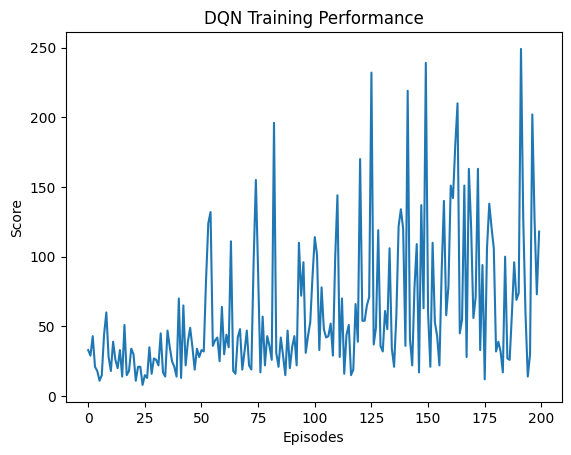

In [ ]:
plt.plot(scores)
plt.title("DQN Training Performance")
plt.xlabel("Episodes")
plt.ylabel("Score")
print("Q2")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ActorCritic(nn.Module):
  def __init__(self, state_dim, action_dim):
    super().__init__()
    self.shared = nn.Sequential(
    nn.Linear(state_dim, 128),
    nn.ReLU()
  )
    self.actor = nn.Linear(128, action_dim)
    self.critic = nn.Linear(128, 1)
  def forward(self, x):
    x = self.shared(x)
    return self.actor(x), self.critic(x)

    ratio = torch.exp(new_log_prob - old_log_prob)
    epsilon = 0.2
    loss = -torch.min(
    ratio * advantage,
    torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantage
    ).mean()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Actor-Critic Network
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )

        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        x = self.shared(x)
        return self.actor(x), self.critic(x)


# ---- Create model ----
state_dim = 4
action_dim = 2

model = ActorCritic(state_dim, action_dim)

# Fake example data
state = torch.randn(1, state_dim)

# Forward pass
logits, value = model(state)

# Convert to probabilities
dist = torch.distributions.Categorical(logits=logits)
action = dist.sample()

new_log_prob = dist.log_prob(action)

# Assume old policy
old_log_prob = new_log_prob.detach()

# Fake advantage
advantage = torch.tensor([1.0])

# PPO Loss
ratio = torch.exp(new_log_prob - old_log_prob)

epsilon = 0.2

loss = -torch.min(
    ratio * advantage,
    torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantage
).mean()

print("Action logits:", logits)
print("State value:", value)
print("Loss:", loss)

Action logits: tensor([[-0.3702, -0.9562]], grad_fn=<AddmmBackward0>)
State value: tensor([[0.2160]], grad_fn=<AddmmBackward0>)
Loss: tensor(-1., grad_fn=<NegBackward0>)
